In [1]:
!pip install rdkit torch-geometric
!pip install --no-deps PyTDC

  Using cached rdkit-2026.3.5-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached torch_geometric-2.8.0.post1-py3-none-any.whl.metadata (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 32.9 MB/s eta 0:00:00
Using cached torch_geometric-2.8.0.post1-py3-none-any.whl (1.3 MB)
  Using cached pytdc-1.1.15.tar.gz (154 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for PyTDC: filename=pytdc-1.1.15-py3-none-any.whl size=191643 sha256=5849ab3a940349c92266af4747caf7f5aa562ff9aaa1da8f073662a0d792f4cc
  Stored in directory: /root/.cache/pip/wheels/3a/51/0f/0b00fd8b8288143eec76ea0a57804cddd72aae207cc4cb4d65
Successfully built PyTDC


In [3]:
!pip install fuzzywuzzy python-Levenshtein

  Using cached fuzzywuzzy-0.18.0-py2.py3-none-any.whl.metadata (4.9 kB)
Using cached fuzzywuzzy-0.18.0-py2.py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.6/157.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytdc 1.1.15 requires cellxgene-census==1.15.0, which is not installed.
pytdc 1.1.15 requires dataclasses<1.0,>=0.6, which is not installed.
pytdc 1.1.15 requires evaluate==0.4.2, which is not installed.
pytdc 1.1.15 requires gget<1.0.0,>=0.28.4, which is not installed.
pytdc 1.1.15 requires tiledbsoma<2.0.0,>=1.7.2, which is not installed.
pytdc 1.1.15 requires accelerate==0.33.0, but you have accelerate 1.14.0 which is incompatible.
pytdc 1.1.15 requires datasets<2.20.0, but you have datasets 4.0.0 which is incompatible.
pytdc 1

Epoch 10/40 | Train Loss (MSE): 0.2681
Epoch 20/40 | Train Loss (MSE): 0.1534
Epoch 30/40 | Train Loss (MSE): 0.1434
Epoch 40/40 | Train Loss (MSE): 0.1535

📊 Boosted Performance:
 -> RMSE: 0.3551 (Lower is better)
 -> R² Score: 0.9665 (Higher is better)


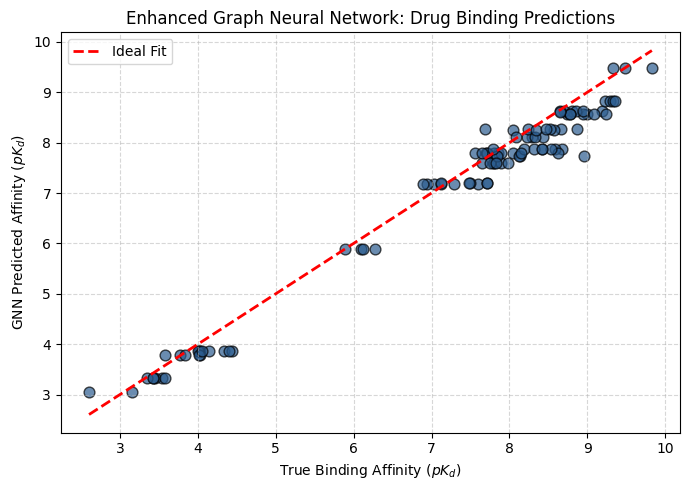

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_add_pool, global_mean_pool

# 1. Enrich Node Features (Atomic Num, Degree, Aromaticity, Hybridization)
def smiles_to_rich_graph(smiles, y_val):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None

    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(
            [
                atom.GetAtomicNum(),
                atom.GetDegree(),
                1.0 if atom.GetIsAromatic() else 0.0,
                float(atom.GetHybridization()),
            ]
        )
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_indices = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_indices.append([i, j])
        edge_indices.append([j, i])

    edge_index = (
        torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        if len(edge_indices) > 0
        else torch.empty((2, 0), dtype=torch.long)
    )
    y = torch.tensor([float(y_val)], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, y=y)


# Process graphs with enriched features
train_graphs = [
    smiles_to_rich_graph(row["SMILES"], row["pKd"])
    for _, row in train_df.iterrows()
    if smiles_to_rich_graph(row["SMILES"], row["pKd"]) is not None
]
test_graphs = [
    smiles_to_rich_graph(row["SMILES"], row["pKd"])
    for _, row in test_df.iterrows()
    if smiles_to_rich_graph(row["SMILES"], row["pKd"]) is not None
]

train_loader = DataLoader(
    train_graphs, batch_size=16, shuffle=True, num_workers=0
)
test_loader = DataLoader(
    test_graphs, batch_size=16, shuffle=False, num_workers=0
)


# 2. Enhanced GNN with Multi-Layer Message Passing & Residuals
class EnhancedGCN(nn.Module):

    def __init__(self, in_channels=4, hidden_channels=128):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, 64)

        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch)

        x = F.relu(self.fc1(x))
        return self.fc2(x)


# 3. Train with Tuned Learning Rate
model = EnhancedGCN().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.003, weight_decay=1e-4
)  # Added weight decay
criterion = nn.MSELoss()

model.train()
for epoch in range(1, 41):
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out.view(-1), batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:02d}/40 | Train Loss (MSE): {total_loss / len(train_loader):.4f}"
        )

# 4. Evaluate
model.eval()
y_true, y_preds = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        y_true.extend(batch.y.cpu().numpy())
        y_preds.extend(out.view(-1).cpu().numpy())

print(f"\n📊 Boosted Performance:")
print(
    f" -> RMSE: {np.sqrt(mean_squared_error(y_true, y_preds)):.4f} (Lower is better)"
)
print(f" -> R² Score: {r2_score(y_true, y_preds):.4f} (Higher is better)")

# Plot Boosted Fit
plt.figure(figsize=(7, 5))
plt.scatter(y_true, y_preds, color="#2b5c8f", alpha=0.7, edgecolors="k", s=60)
plt.plot(
    [min(y_true), max(y_true)],
    [min(y_true), max(y_true)],
    "r--",
    lw=2,
    label="Ideal Fit",
)
plt.xlabel("True Binding Affinity ($pK_d$)")
plt.ylabel("GNN Predicted Affinity ($pK_d$)")
plt.title("Enhanced Graph Neural Network: Drug Binding Predictions")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Save final weights
torch.save(model.state_dict(), "gcn_binding_model.pth")